PROJECT_ROOT: /home/iailab42/khans1/projects/ir
REAL_DIR: /home/iailab42/khans1/projects/ir/data
SYNTHETIC_CANDIDATE: prior
SYNTHETIC_NAME: KoVAE prior
SYN_DIR: /home/iailab42/khans1/projects/ir/data/synthetic/prior
Plot output: /home/iailab42/khans1/projects/ir/figures/comparison/prior
Array output: /home/iailab42/khans1/projects/ir/results/comparison/prior
Checking metadata timeline for: prior
Unique start samples before fix: 1
Unique end samples before fix: 1
Backup saved: /home/iailab42/khans1/projects/ir/data/synthetic/prior/all_metadata_synthetic_before_timeline_fix.csv
Metadata timeline fixed.
Saved: /home/iailab42/khans1/projects/ir/data/synthetic/prior/all_metadata_synthetic.csv

SYN_001 check:
Rows: 800
Unique start samples: 800
Unique end samples: 800
Min start: 0
Max end: 102784
Duration sec: 1606.0
Duration min: 26.766666666666666
Loading real data
Loading synthetic data: KoVAE prior

Real X: (46907, 512, 6)
Synthetic X: (8000, 512, 6)

Available real subjects:
['S1', 'S10

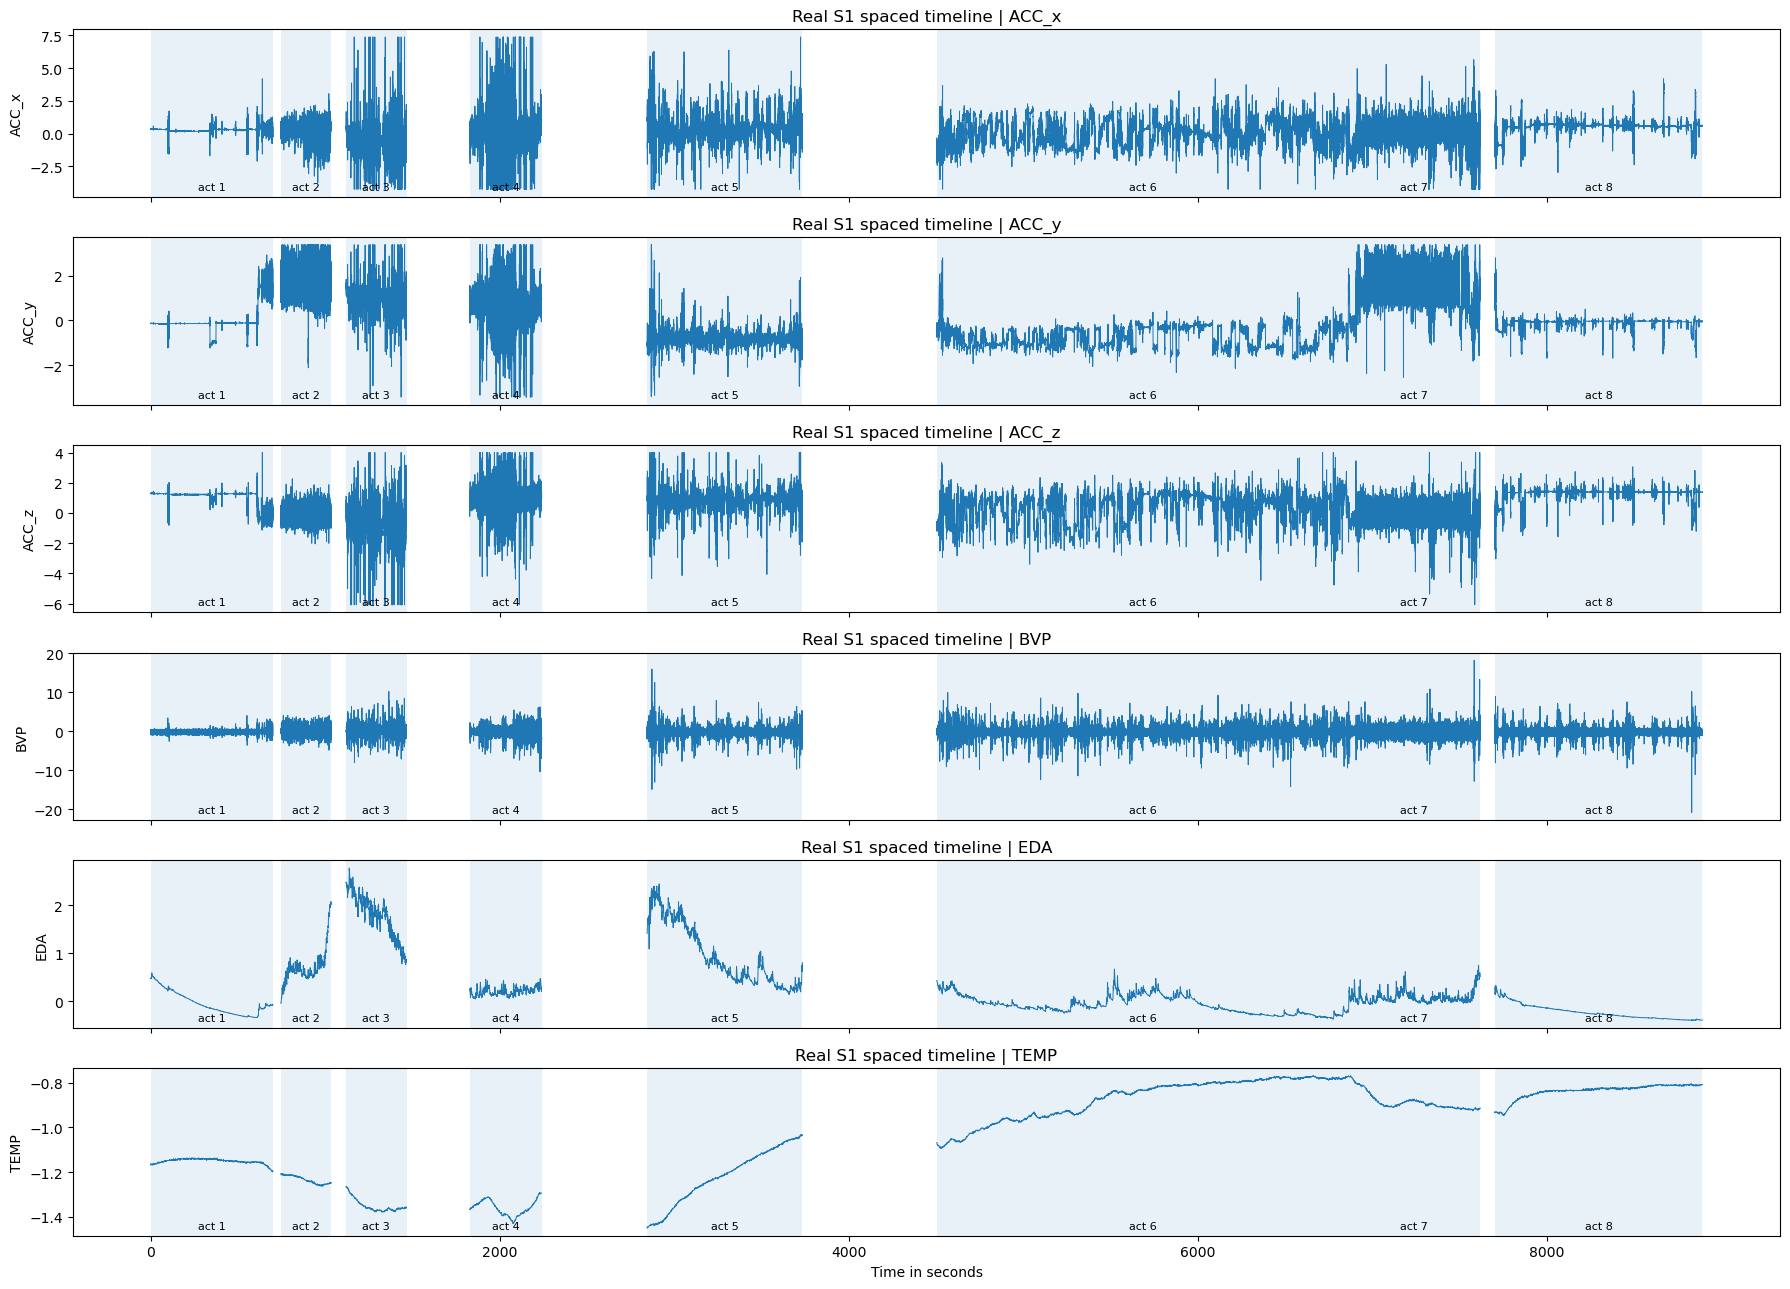


Reconstructing real stitched subject: S1
Real stitched windows: (3445, 512, 6)
Real stitched continuous: (441344, 6)
Real stitched duration min: 114.93333333333334
Real stitched label counts: {np.int64(1): np.int64(347), np.int64(2): np.int64(141), np.int64(3): np.int64(170), np.int64(4): np.int64(203), np.int64(5): np.int64(442), np.int64(6): np.int64(1175), np.int64(7): np.int64(375), np.int64(8): np.int64(592)}
Saved continuous arrays: /home/iailab42/khans1/projects/ir/results/comparison/prior/real_S1_stitched.npz
Saved plot: /home/iailab42/khans1/projects/ir/figures/comparison/prior/real_S1_stitched_timeline_all_channels.png


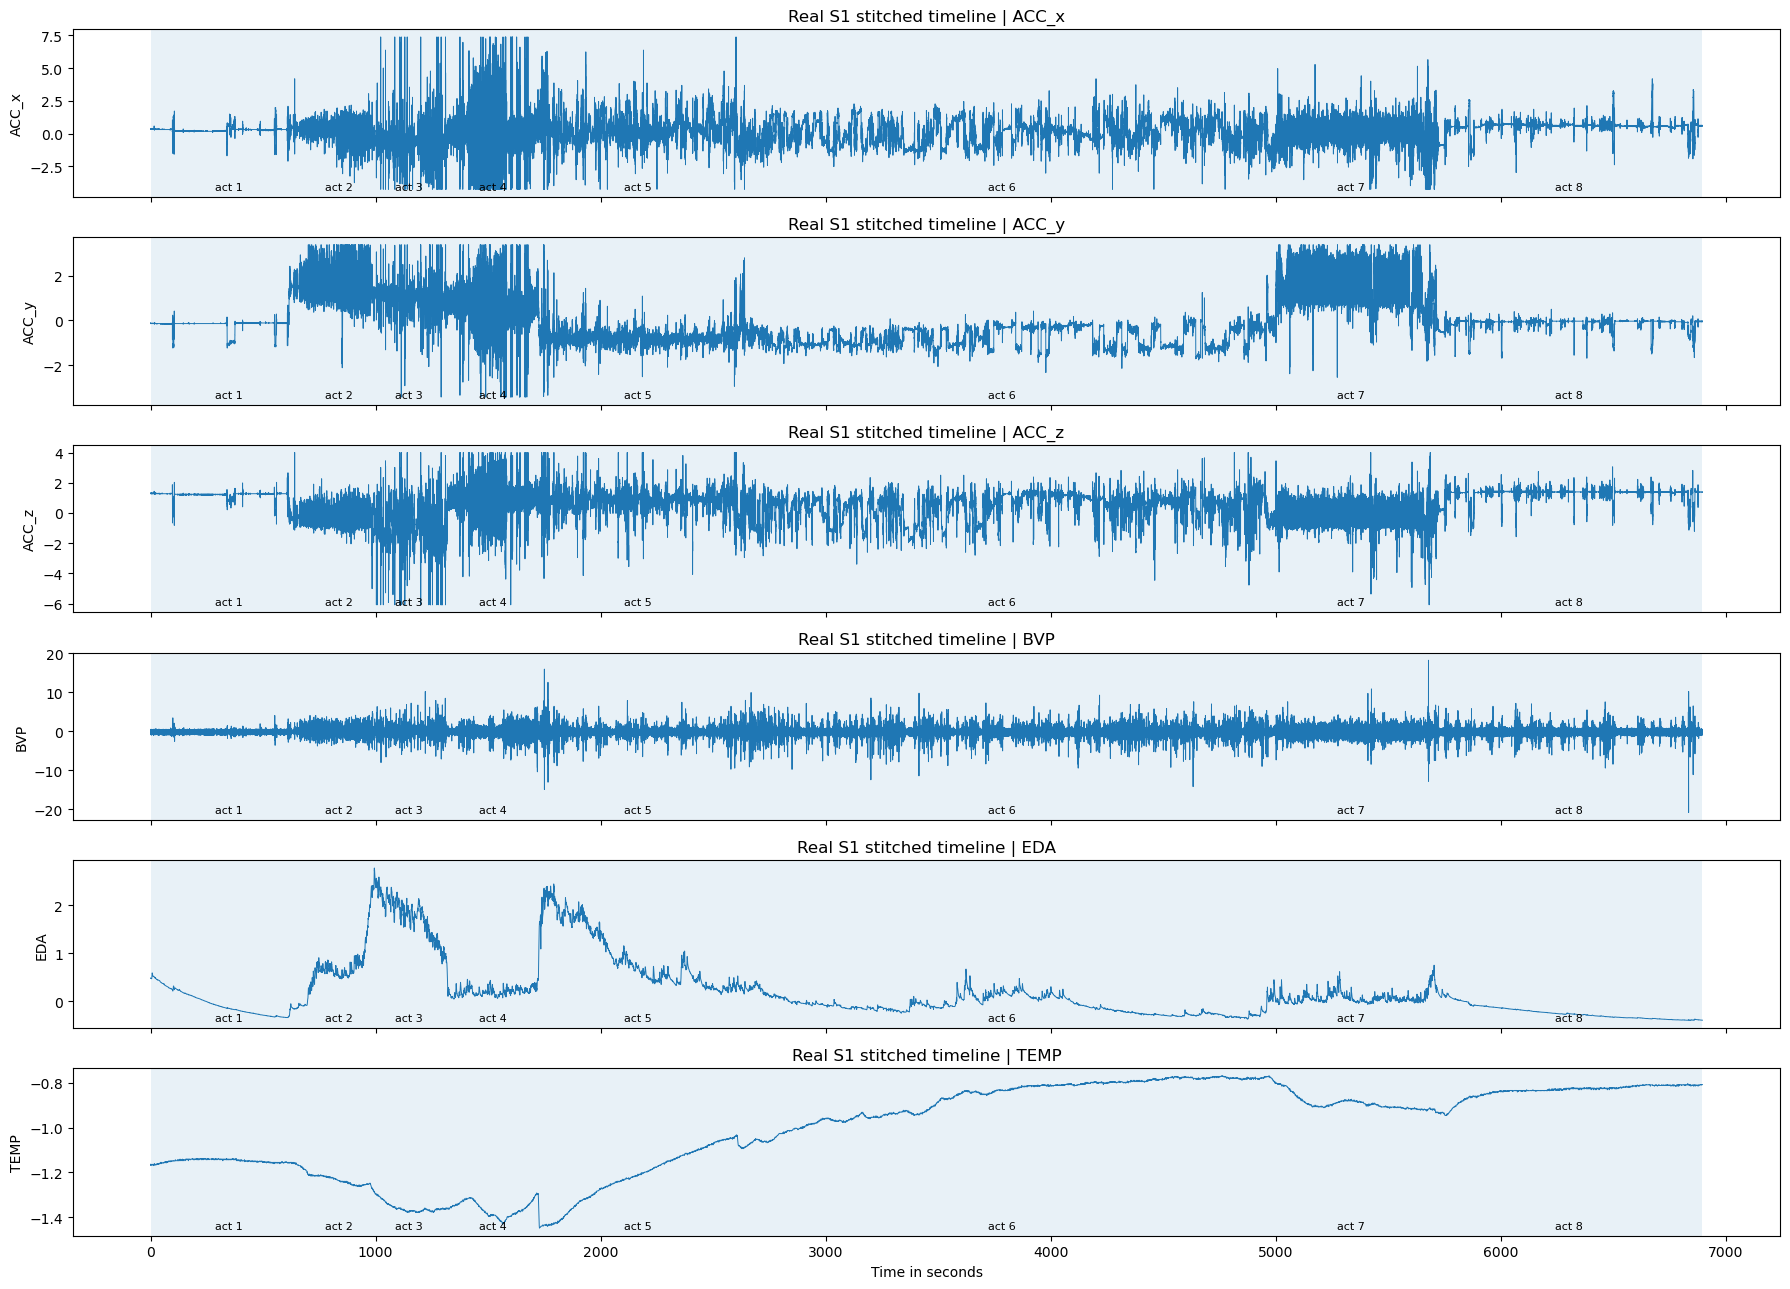


Reconstructing synthetic subject: SYN_001
Synthetic method: KoVAE prior
Synthetic windows: (800, 512, 6)
Synthetic continuous: (102784, 6)
Synthetic duration min: 26.766666666666666
Synthetic label counts: {np.int64(1): np.int64(100), np.int64(2): np.int64(100), np.int64(3): np.int64(100), np.int64(4): np.int64(100), np.int64(5): np.int64(100), np.int64(6): np.int64(100), np.int64(7): np.int64(100), np.int64(8): np.int64(100)}
Saved continuous arrays: /home/iailab42/khans1/projects/ir/results/comparison/prior/prior_SYN_001.npz
Saved plot: /home/iailab42/khans1/projects/ir/figures/comparison/prior/prior_SYN_001_timeline_all_channels.png


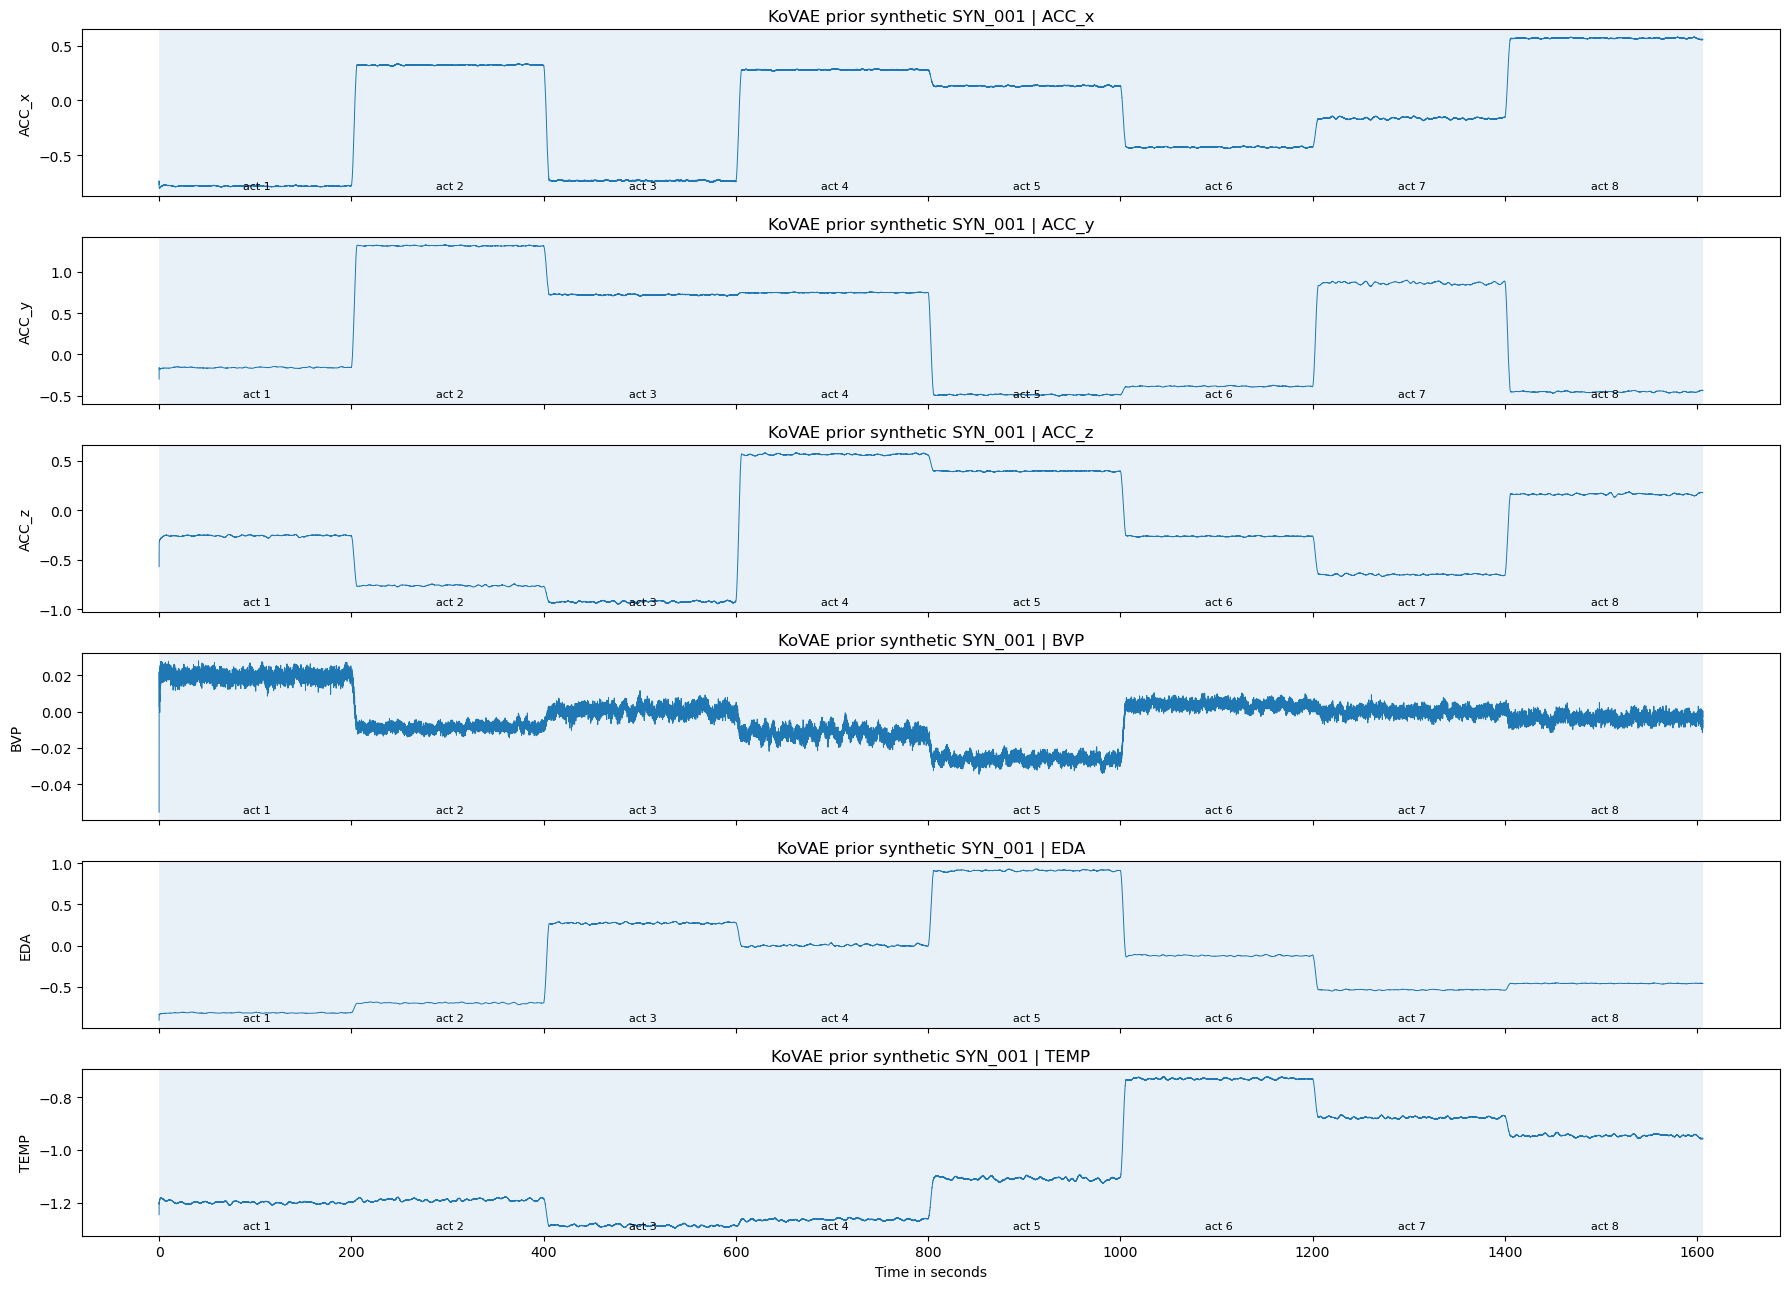


Three-way channel comparison
Synthetic method: KoVAE prior
Saved plot: /home/iailab42/khans1/projects/ir/figures/comparison/prior/prior_three_way_ACC_x.png


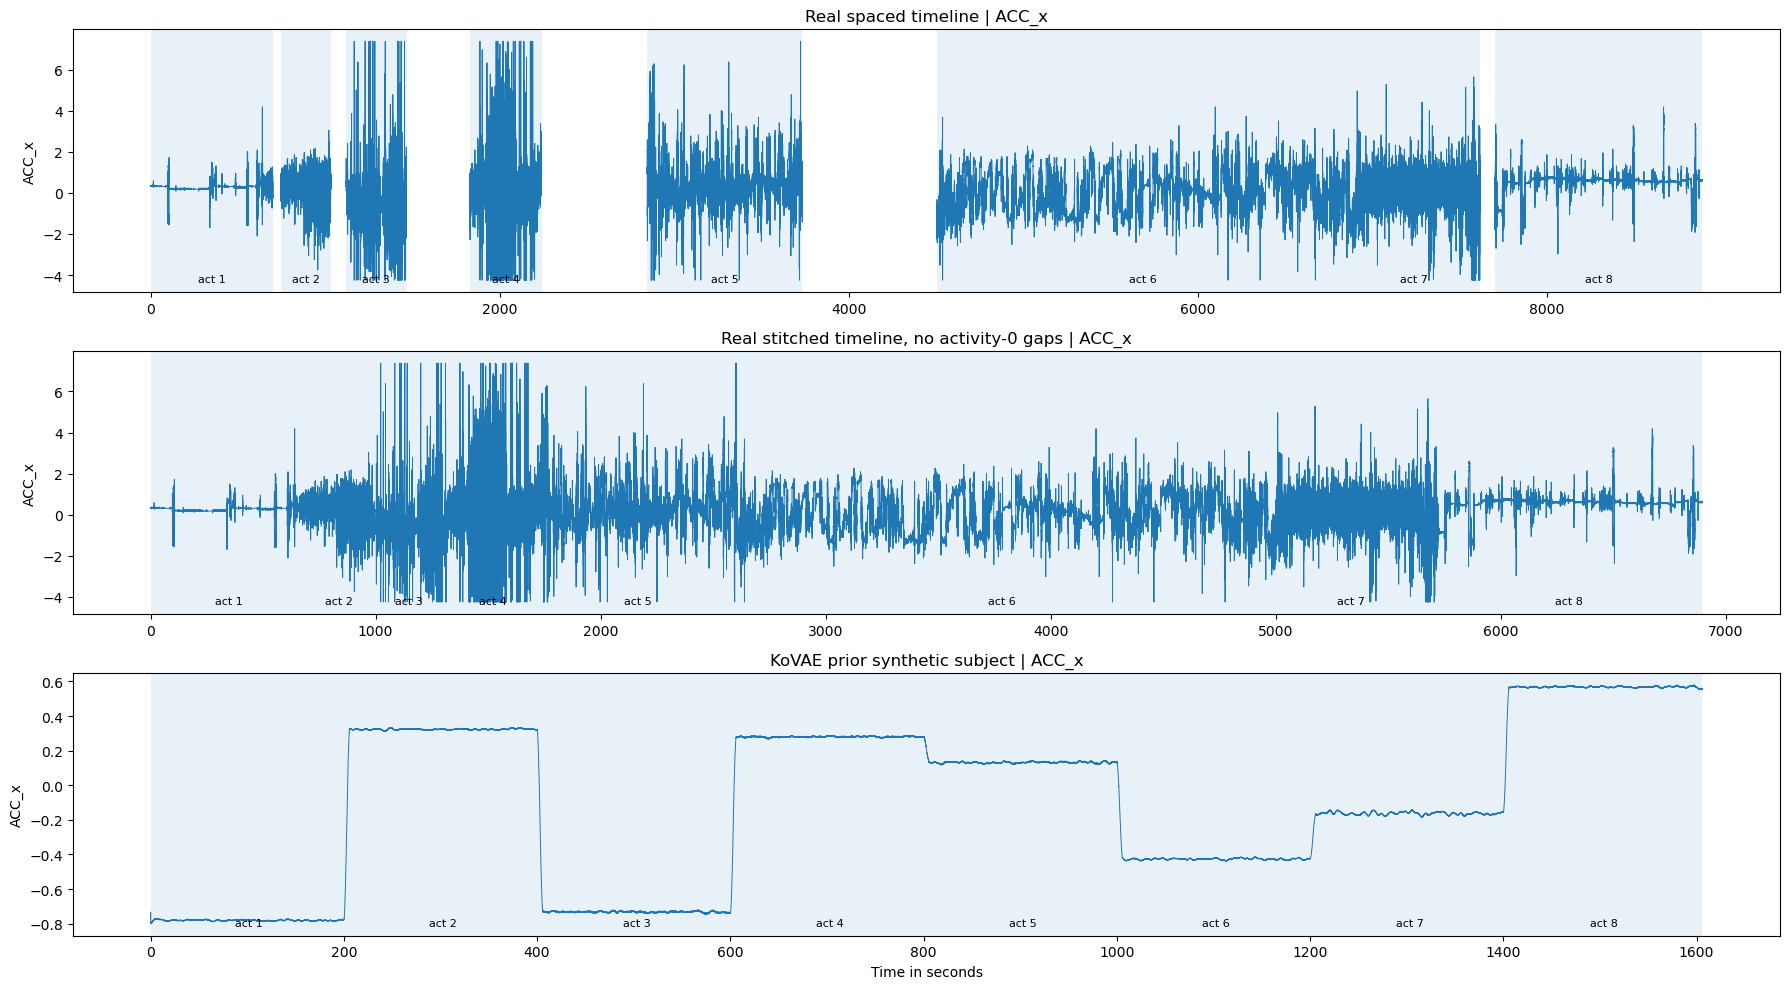

Saved plot: /home/iailab42/khans1/projects/ir/figures/comparison/prior/prior_three_way_ACC_y.png


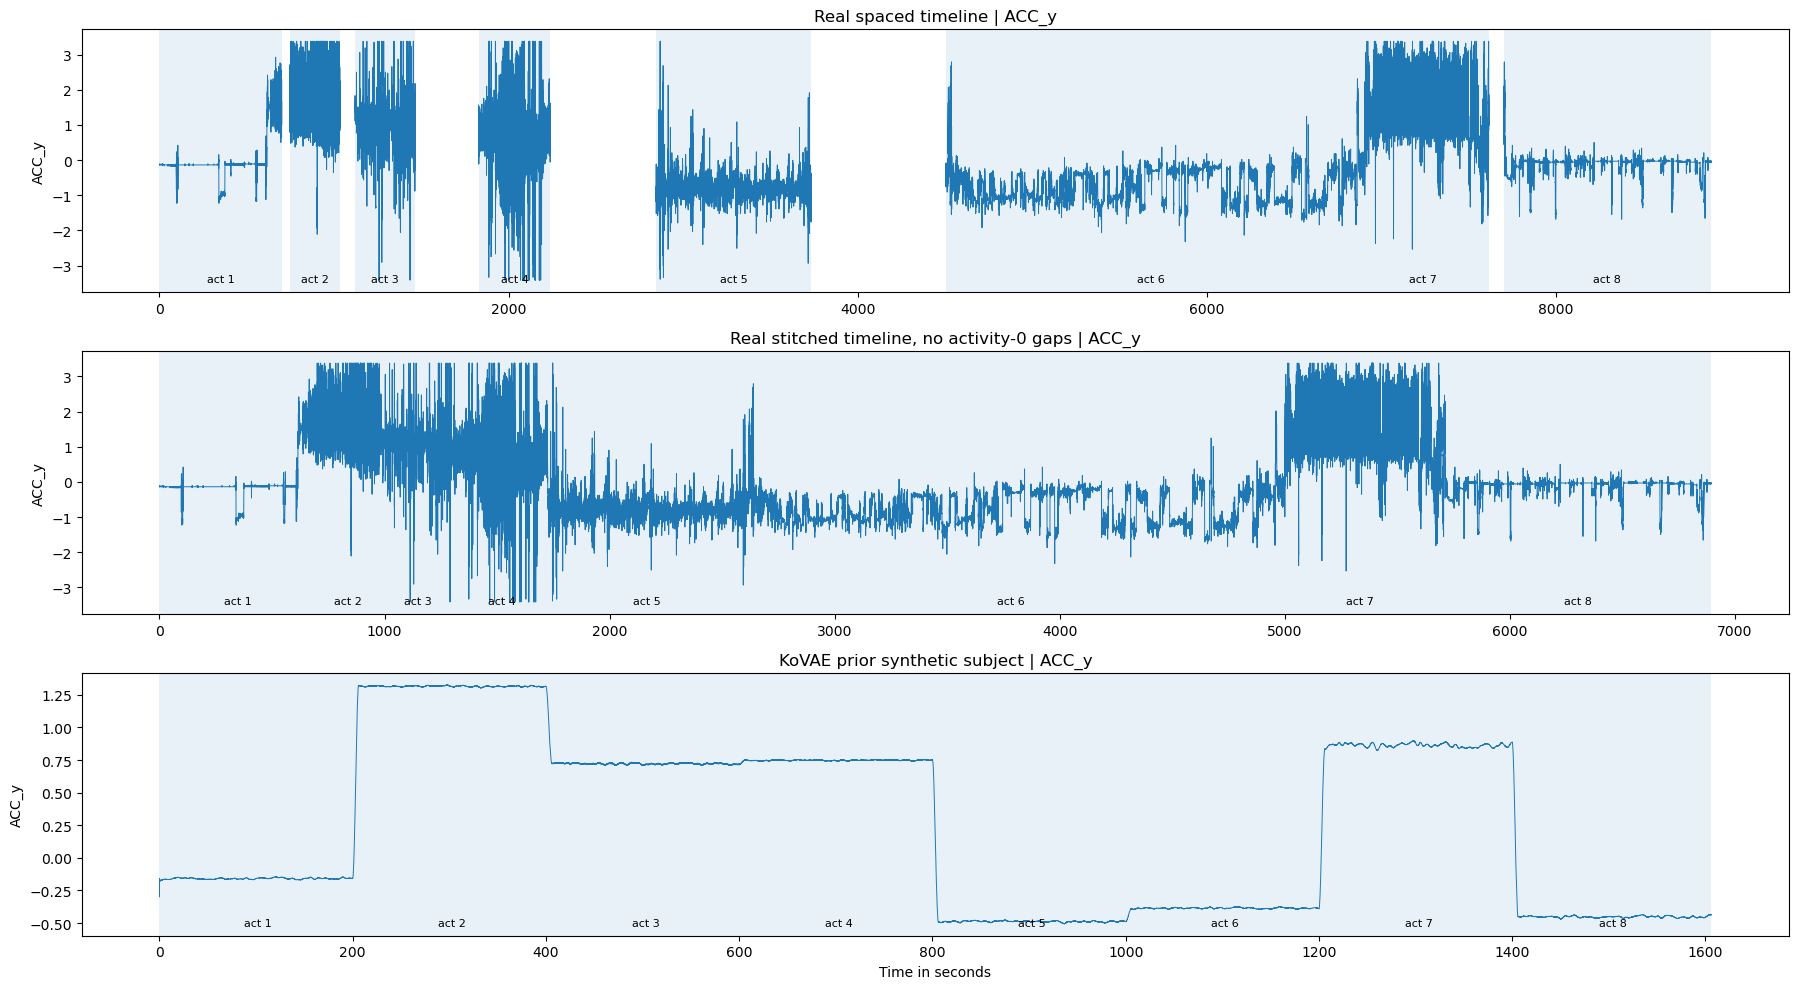

Saved plot: /home/iailab42/khans1/projects/ir/figures/comparison/prior/prior_three_way_ACC_z.png


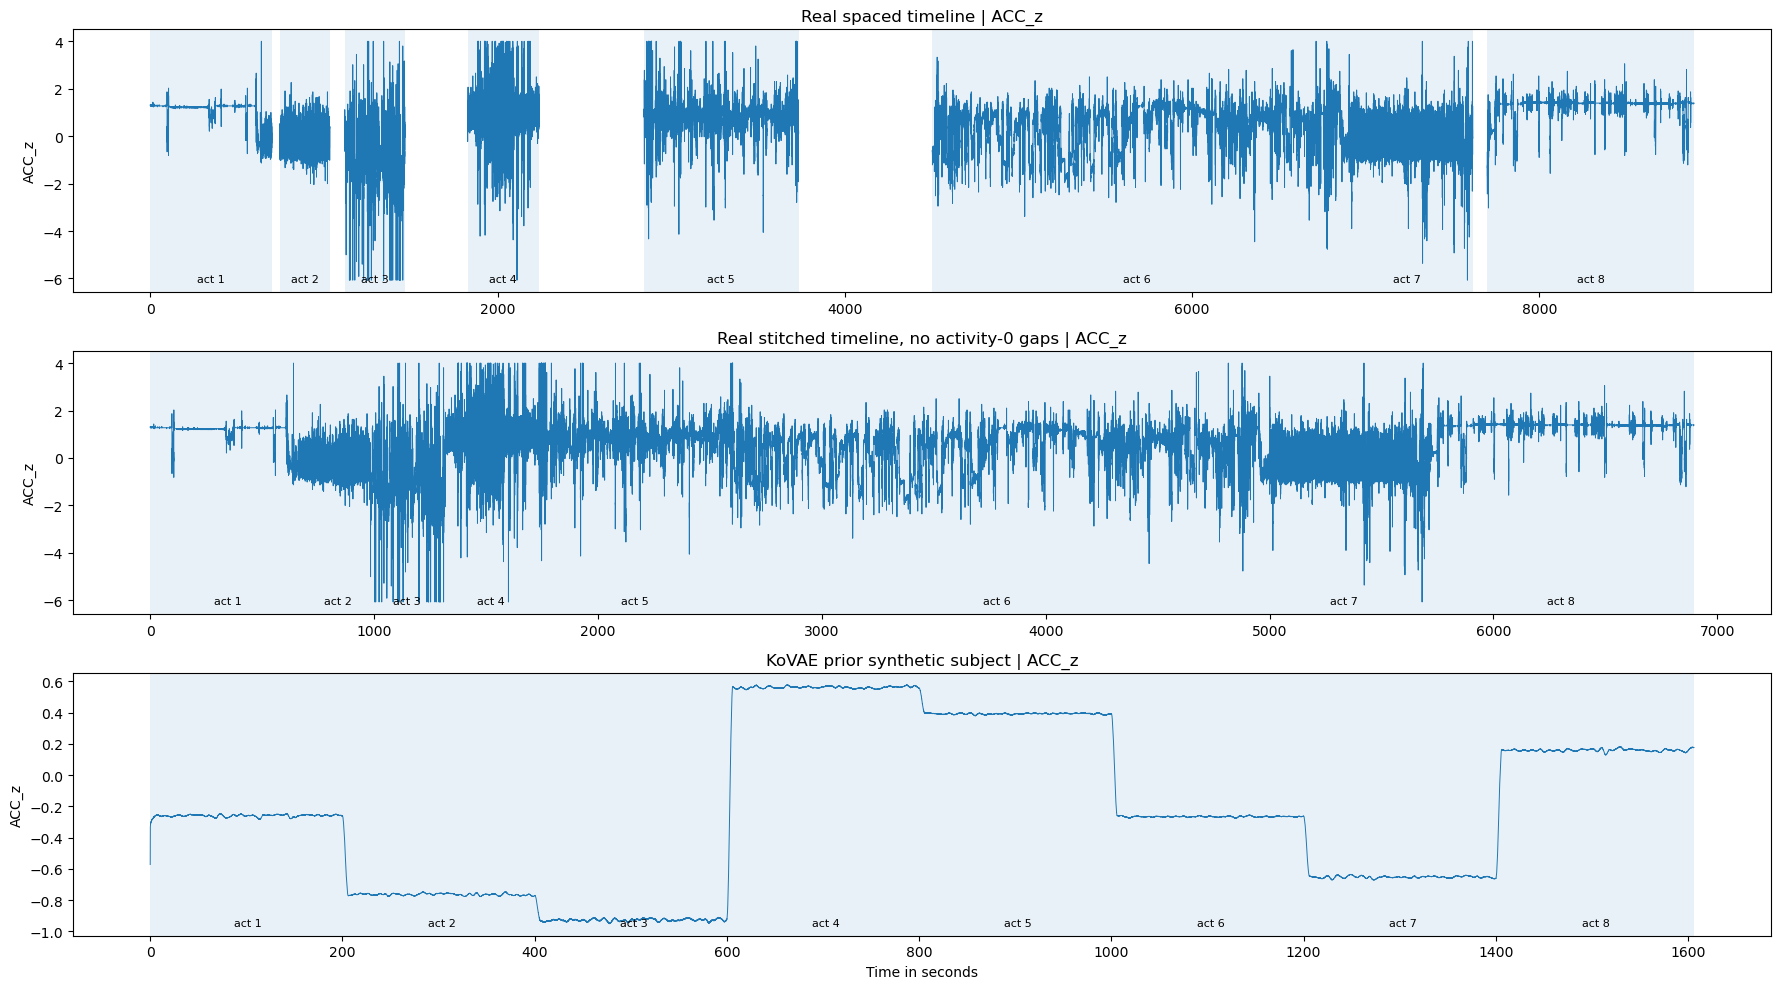

Saved plot: /home/iailab42/khans1/projects/ir/figures/comparison/prior/prior_three_way_BVP.png


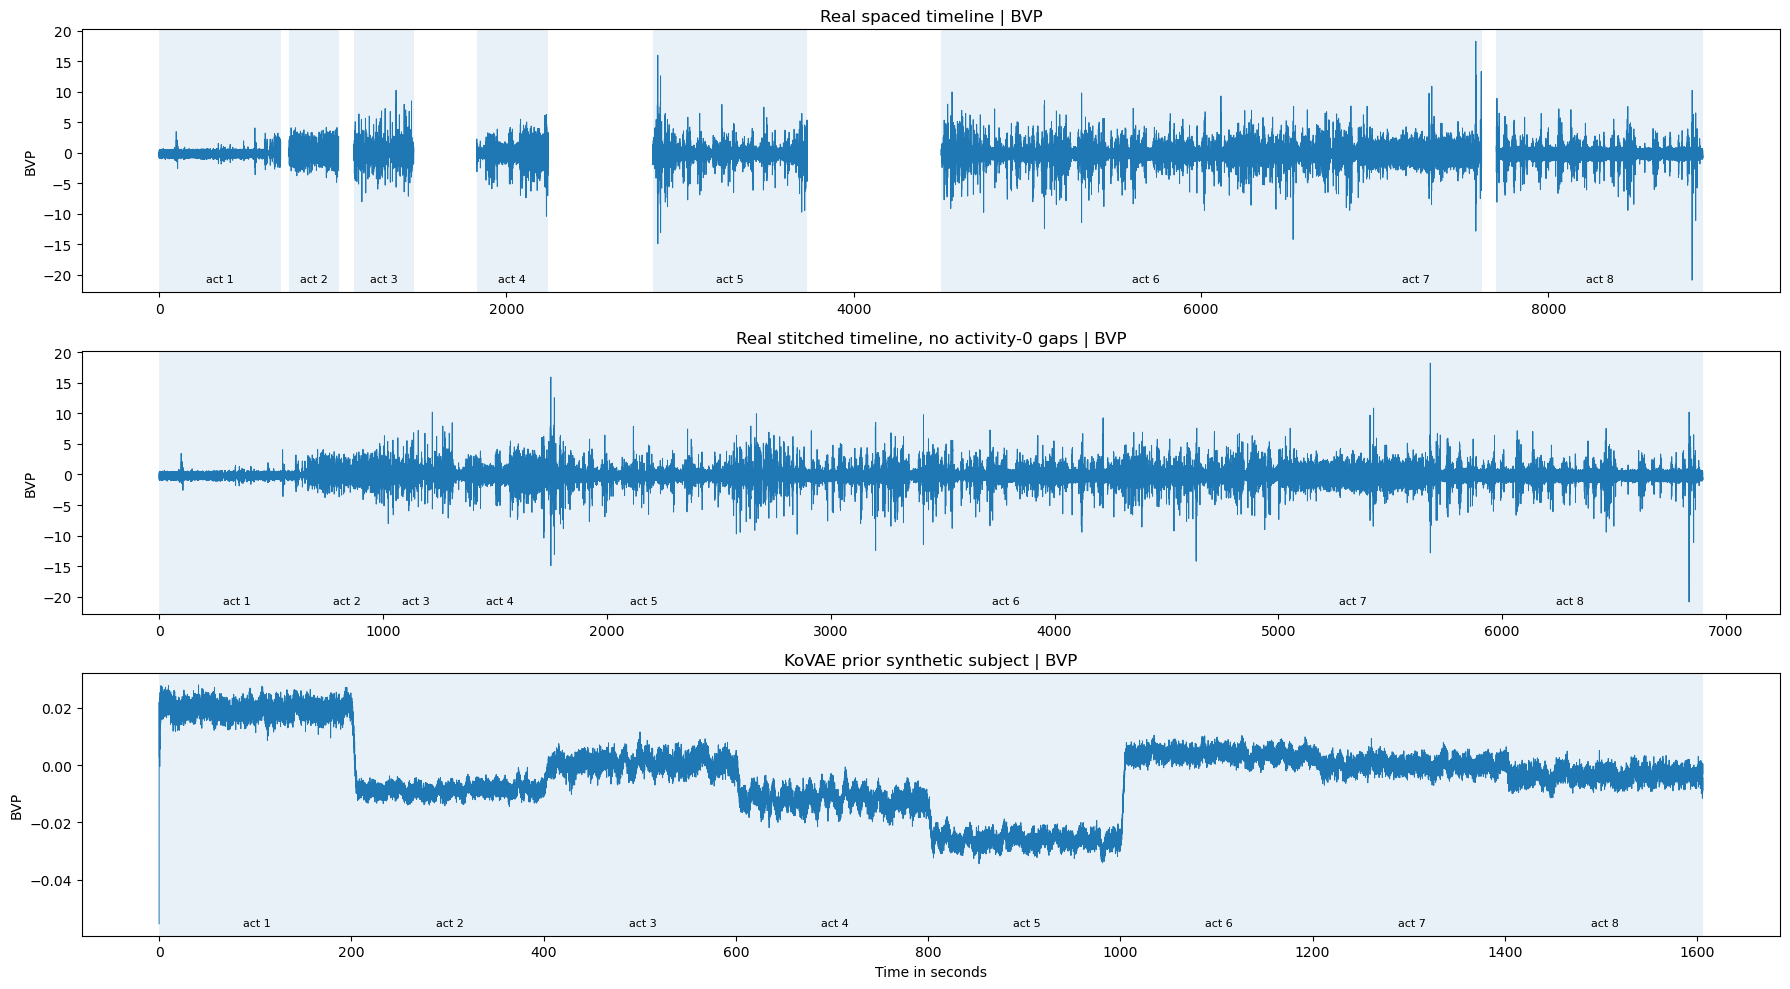

Saved plot: /home/iailab42/khans1/projects/ir/figures/comparison/prior/prior_three_way_EDA.png


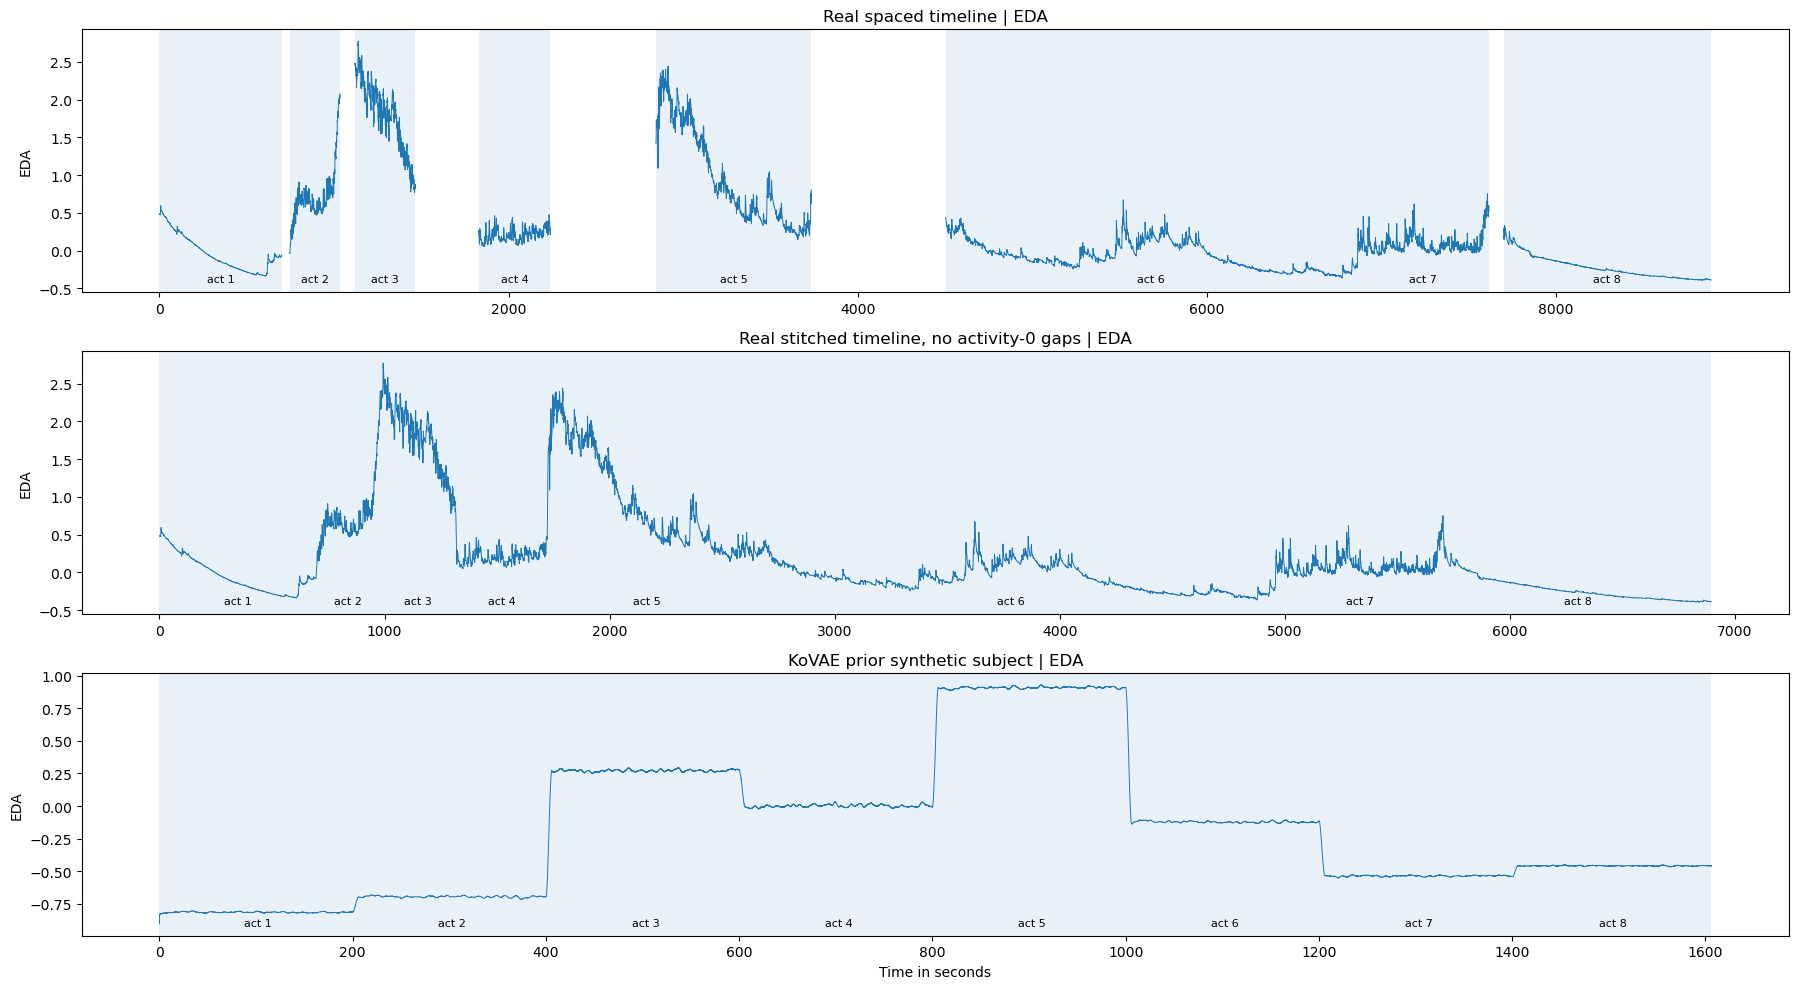

Saved plot: /home/iailab42/khans1/projects/ir/figures/comparison/prior/prior_three_way_TEMP.png


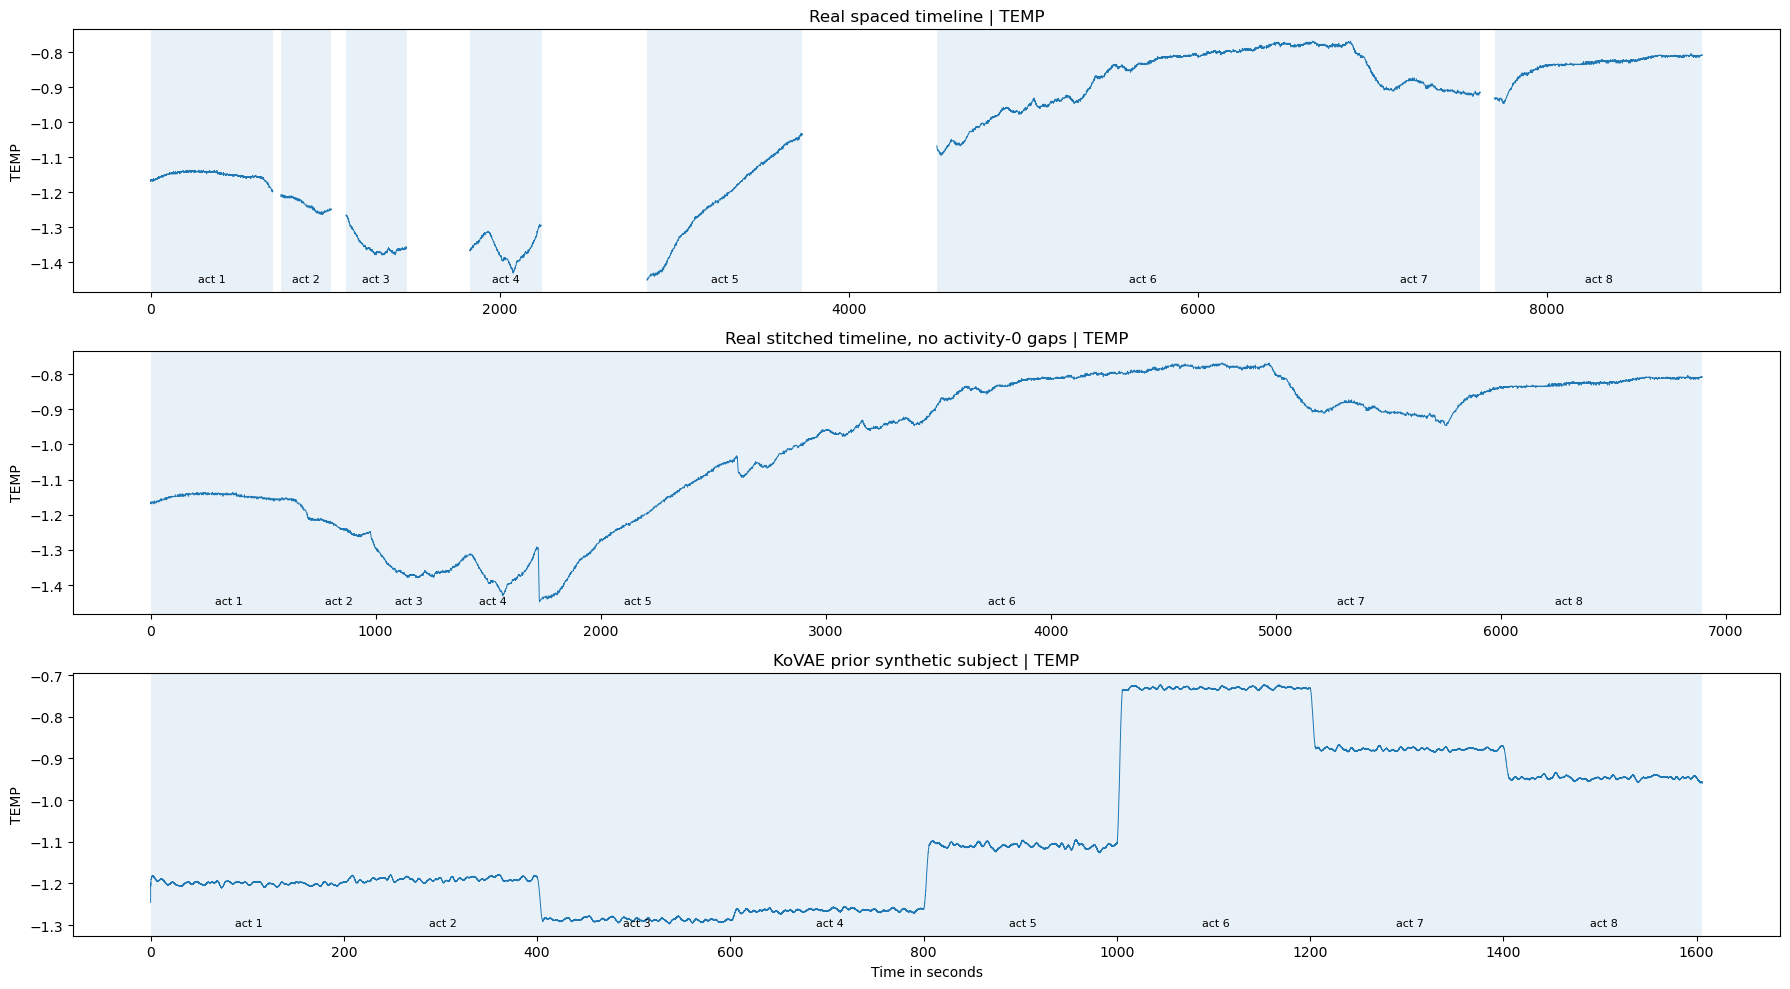


Comparison finished.
Plots saved to: /home/iailab42/khans1/projects/ir/figures/comparison/prior
Arrays saved to: /home/iailab42/khans1/projects/ir/results/comparison/prior


In [ ]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# Project paths
# ============================================================

PROJECT_ROOT = Path("/home/iailab42/khans1/projects/ir")

REAL_DIR = PROJECT_ROOT / "data"
SYNTHETIC_ROOT = PROJECT_ROOT / "data" / "synthetic"

REAL_X_PATH = REAL_DIR / "all_X.npy"
REAL_Y_PATH = REAL_DIR / "all_y.npy"
REAL_SUBJECT_PATH = REAL_DIR / "all_subject.npy"
REAL_METADATA_PATH = REAL_DIR / "all_metadata.csv"


# ============================================================
# Synthetic candidate selection
# ============================================================

# SYNTHETIC_CANDIDATE = "posterior_bank"
SYNTHETIC_CANDIDATE = "prior"
# SYNTHETIC_CANDIDATE = "timevae"

SYNTHETIC_CANDIDATES = {
    "posterior_bank": {
        "name": "KoVAE posterior-bank",
        "dir": SYNTHETIC_ROOT / "posterior_bank",
    },
    "prior": {
        "name": "KoVAE prior",
        "dir": SYNTHETIC_ROOT / "prior",
    },
    "timevae": {
        "name": "TimeVAE",
        "dir": SYNTHETIC_ROOT / "timevae",
    },
}

if SYNTHETIC_CANDIDATE not in SYNTHETIC_CANDIDATES:
    raise ValueError(
        f"Unknown synthetic candidate: {SYNTHETIC_CANDIDATE}. "
        f"Available candidates: {list(SYNTHETIC_CANDIDATES.keys())}"
    )

SYNTHETIC_NAME = SYNTHETIC_CANDIDATES[SYNTHETIC_CANDIDATE]["name"]
SYN_DIR = SYNTHETIC_CANDIDATES[SYNTHETIC_CANDIDATE]["dir"]

SYN_X_PATH = SYN_DIR / "all_X_synthetic.npy"
SYN_Y_PATH = SYN_DIR / "all_y_synthetic.npy"
SYN_SUBJECT_PATH = SYN_DIR / "all_subject_synthetic.npy"
SYN_METADATA_PATH = SYN_DIR / "all_metadata_synthetic.csv"


# ============================================================
# Output folders
# ============================================================

OUT_DIR = PROJECT_ROOT / "figures" / "comparison" / SYNTHETIC_CANDIDATE
ARRAY_OUT_DIR = PROJECT_ROOT / "results" / "comparison" / SYNTHETIC_CANDIDATE

OUT_DIR.mkdir(parents=True, exist_ok=True)
ARRAY_OUT_DIR.mkdir(parents=True, exist_ok=True)

SAVE_PLOTS = True
SAVE_CONTINUOUS_ARRAYS = True
PLOT_DPI = 200

print("PROJECT_ROOT:", PROJECT_ROOT)
print("REAL_DIR:", REAL_DIR)
print("SYNTHETIC_CANDIDATE:", SYNTHETIC_CANDIDATE)
print("SYNTHETIC_NAME:", SYNTHETIC_NAME)
print("SYN_DIR:", SYN_DIR)
print("Plot output:", OUT_DIR)
print("Array output:", ARRAY_OUT_DIR)

# ============================================================
# Signal and plotting constants
# ============================================================

TARGET_HZ = 64
WINDOW_LEN = 512
SHIFT_LEN = 128

CHANNEL_NAMES = ["ACC_x", "ACC_y", "ACC_z", "BVP", "EDA", "TEMP"]
NUM_CHANNELS = len(CHANNEL_NAMES)

REAL_SUBJECT_TO_PLOT = "S1"
SYN_SUBJECT_TO_PLOT = "SYN_001"

WEIGHT_MODE = "hann"
PLOT_STEP = 1

# ============================================================
# Synthetic metadata timeline fix
# ============================================================

# AUTO_FIX_SYNTHETIC_METADATA = True

# def fix_synthetic_metadata_timeline(
#     syn_dir: Path,
#     synthetic_candidate: str,
#     window_len: int = WINDOW_LEN,
#     shift_len: int = SHIFT_LEN,
#     target_hz: int = TARGET_HZ,
# ) -> None:
#     metadata_path = syn_dir / "all_metadata_synthetic.csv"
#     backup_path = syn_dir / "all_metadata_synthetic_before_timeline_fix.csv"

#     if not metadata_path.exists():
#         raise FileNotFoundError(f"Synthetic metadata not found: {metadata_path}")

#     metadata = pd.read_csv(metadata_path)

#     if "synthetic_subject" not in metadata.columns:
#         raise ValueError("Synthetic metadata must contain 'synthetic_subject'.")

#     start_unique = metadata["start_sample_64hz"].nunique()
#     end_unique = metadata["end_sample_64hz"].nunique()

#     print(f"Checking metadata timeline for: {synthetic_candidate}")
#     print("Unique start samples before fix:", start_unique)
#     print("Unique end samples before fix:", end_unique)

#     if start_unique > 1 and end_unique > 1:
#         print("Metadata timeline already looks valid. No fix applied.")
#         return

#     if not backup_path.exists():
#         metadata.to_csv(backup_path, index=False)
#         print("Backup saved:", backup_path)

#     metadata = metadata.copy()

#     metadata["synthetic_window_in_subject"] = (
#         metadata.groupby("synthetic_subject").cumcount()
#     )

#     metadata["start_sample_64hz"] = metadata["synthetic_window_in_subject"] * shift_len
#     metadata["end_sample_64hz"] = metadata["start_sample_64hz"] + window_len

#     metadata["start_time_sec"] = metadata["start_sample_64hz"] / target_hz
#     metadata["end_time_sec"] = metadata["end_sample_64hz"] / target_hz

#     metadata.to_csv(metadata_path, index=False)

#     check = metadata[metadata["synthetic_subject"] == "SYN_001"]

#     print("Metadata timeline fixed.")
#     print("Saved:", metadata_path)
#     print("\nSYN_001 check:")
#     print("Rows:", len(check))
#     print("Unique start samples:", check["start_sample_64hz"].nunique())
#     print("Unique end samples:", check["end_sample_64hz"].nunique())
#     print("Min start:", check["start_sample_64hz"].min())
#     print("Max end:", check["end_sample_64hz"].max())
#     print("Duration sec:", check["end_sample_64hz"].max() / target_hz)
#     print("Duration min:", check["end_sample_64hz"].max() / target_hz / 60)


# if AUTO_FIX_SYNTHETIC_METADATA:
#     fix_synthetic_metadata_timeline(
#         syn_dir=SYN_DIR,
#         synthetic_candidate=SYNTHETIC_CANDIDATE,
#     )

# ============================================================
# Data loading helpers
# ============================================================

def require_file(path: Path) -> Path:
    path = Path(path)

    if not path.exists():
        raise FileNotFoundError(f"Missing file: {path}")

    return path


def check_window_shape(X: np.ndarray, expected_channels: int, name: str) -> None:
    if X.ndim != 3:
        raise ValueError(f"{name}: expected [N, T, C], got {X.shape}")

    if X.shape[1] != WINDOW_LEN:
        raise ValueError(f"{name}: expected window length {WINDOW_LEN}, got {X.shape[1]}")

    if X.shape[2] != expected_channels:
        raise ValueError(f"{name}: expected {expected_channels} channels, got {X.shape[2]}")


def load_real_data():
    require_file(REAL_X_PATH)
    require_file(REAL_Y_PATH)
    require_file(REAL_SUBJECT_PATH)
    require_file(REAL_METADATA_PATH)

    X = np.load(REAL_X_PATH).astype(np.float32)
    y = np.load(REAL_Y_PATH).astype(np.int64)
    subjects = np.load(REAL_SUBJECT_PATH, allow_pickle=True).astype(str)
    metadata = pd.read_csv(REAL_METADATA_PATH)

    check_window_shape(X, NUM_CHANNELS, "Real X")

    required_columns = ["start_sample_64hz", "end_sample_64hz"]
    missing_columns = [column for column in required_columns if column not in metadata.columns]

    if missing_columns:
        raise ValueError(f"Real metadata missing columns: {missing_columns}")

    metadata = metadata.copy()
    metadata["subject"] = subjects
    metadata["activity_label"] = y
    metadata["array_index"] = np.arange(len(y), dtype=np.int64)

    return X, y, subjects, metadata


def load_synthetic_data():
    require_file(SYN_X_PATH)
    require_file(SYN_Y_PATH)
    require_file(SYN_SUBJECT_PATH)
    require_file(SYN_METADATA_PATH)

    X = np.load(SYN_X_PATH).astype(np.float32)
    y = np.load(SYN_Y_PATH).astype(np.int64)
    subjects = np.load(SYN_SUBJECT_PATH, allow_pickle=True).astype(str)
    metadata = pd.read_csv(SYN_METADATA_PATH)

    check_window_shape(X, NUM_CHANNELS, "Synthetic X")

    required_columns = ["start_sample_64hz", "end_sample_64hz"]
    missing_columns = [column for column in required_columns if column not in metadata.columns]

    if missing_columns:
        raise ValueError(f"Synthetic metadata missing columns: {missing_columns}")

    metadata = metadata.copy()
    metadata["synthetic_subject"] = subjects
    metadata["activity_label"] = y
    metadata["array_index"] = np.arange(len(y), dtype=np.int64)

    return X, y, subjects, metadata

# ============================================================
# Continuous signal reconstruction
# ============================================================

def make_window_weights(window_len: int, weight_mode: str = "hann") -> np.ndarray:
    if weight_mode == "hann":
        weights = np.hanning(window_len).astype(np.float32)
        weights = np.maximum(weights, 1e-3)
    elif weight_mode == "ones":
        weights = np.ones(window_len, dtype=np.float32)
    else:
        raise ValueError("weight_mode must be either 'hann' or 'ones'.")

    return weights[:, None]


def reconstruct_overlap_add(
    windows: np.ndarray,
    labels: np.ndarray,
    start_samples: np.ndarray,
    end_samples: np.ndarray,
    window_len: int = WINDOW_LEN,
    weight_mode: str = WEIGHT_MODE,
):
    windows = np.asarray(windows, dtype=np.float32)
    labels = np.asarray(labels, dtype=np.int64)
    start_samples = np.asarray(start_samples, dtype=np.int64)
    end_samples = np.asarray(end_samples, dtype=np.int64)

    offset = int(start_samples.min())
    start_samples = start_samples - offset
    end_samples = end_samples - offset

    total_len = int(end_samples.max())
    num_channels = windows.shape[2]

    continuous_sum = np.zeros((total_len, num_channels), dtype=np.float32)
    weight_sum = np.zeros((total_len, 1), dtype=np.float32)

    max_label = max(8, int(labels.max()))
    label_scores = np.zeros((total_len, max_label + 1), dtype=np.float32)

    window_weight = make_window_weights(window_len, weight_mode)

    for i in range(len(windows)):
        start = int(start_samples[i])
        end = int(end_samples[i])

        if end <= start:
            continue

        if end - start != window_len:
            raise ValueError(f"Window {i} has length {end - start}, expected {window_len}.")

        continuous_sum[start:end] += windows[i] * window_weight
        weight_sum[start:end] += window_weight

        label = int(labels[i])

        if 0 <= label < label_scores.shape[1]:
            label_scores[start:end, label] += window_weight[:, 0]

    covered = weight_sum[:, 0] > 1e-8

    continuous = np.full_like(continuous_sum, np.nan, dtype=np.float32)
    continuous[covered] = continuous_sum[covered] / weight_sum[covered]

    sample_labels = np.zeros(total_len, dtype=np.int64)
    sample_labels[covered] = np.argmax(label_scores[covered], axis=1)

    coverage = weight_sum[:, 0]

    return continuous, sample_labels, coverage

# ============================================================
# Window selection for real and synthetic subjects
# ============================================================

def get_real_subject_windows_spaced(X: np.ndarray, metadata: pd.DataFrame, subject_name: str):
    subject_metadata = metadata[metadata["subject"] == subject_name].copy()

    if len(subject_metadata) == 0:
        raise ValueError(f"Real subject not found: {subject_name}")

    subject_metadata = subject_metadata.sort_values("start_sample_64hz").reset_index(drop=True)

    indices = subject_metadata["array_index"].to_numpy(dtype=np.int64)
    windows = X[indices]
    labels = subject_metadata["activity_label"].to_numpy(dtype=np.int64)
    start_samples = subject_metadata["start_sample_64hz"].to_numpy(dtype=np.int64)
    end_samples = subject_metadata["end_sample_64hz"].to_numpy(dtype=np.int64)

    return windows, labels, start_samples, end_samples, subject_metadata


def get_real_subject_windows_stitched(X: np.ndarray, metadata: pd.DataFrame, subject_name: str):
    subject_metadata = metadata[metadata["subject"] == subject_name].copy()

    if len(subject_metadata) == 0:
        raise ValueError(f"Real subject not found: {subject_name}")

    subject_metadata = subject_metadata.sort_values("start_sample_64hz").reset_index(drop=True)

    indices = subject_metadata["array_index"].to_numpy(dtype=np.int64)
    windows = X[indices]
    labels = subject_metadata["activity_label"].to_numpy(dtype=np.int64)

    start_samples = np.arange(len(subject_metadata), dtype=np.int64) * SHIFT_LEN
    end_samples = start_samples + WINDOW_LEN

    return windows, labels, start_samples, end_samples, subject_metadata


def get_synthetic_subject_windows(X: np.ndarray, metadata: pd.DataFrame, subject_name: str):
    subject_metadata = metadata[metadata["synthetic_subject"] == subject_name].copy()

    if len(subject_metadata) == 0:
        available_subjects = sorted(metadata["synthetic_subject"].unique().tolist())
        raise ValueError(
            f"Synthetic subject not found: {subject_name}. "
            f"Available examples: {available_subjects[:20]}"
        )

    if "synthetic_window_in_subject" in subject_metadata.columns:
        subject_metadata = subject_metadata.sort_values("synthetic_window_in_subject").reset_index(drop=True)
    else:
        subject_metadata = subject_metadata.sort_values("start_sample_64hz").reset_index(drop=True)

    indices = subject_metadata["array_index"].to_numpy(dtype=np.int64)
    windows = X[indices]
    labels = subject_metadata["activity_label"].to_numpy(dtype=np.int64)
    start_samples = subject_metadata["start_sample_64hz"].to_numpy(dtype=np.int64)
    end_samples = subject_metadata["end_sample_64hz"].to_numpy(dtype=np.int64)

    return windows, labels, start_samples, end_samples, subject_metadata

# ============================================================
# Plotting helpers
# ============================================================

def safe_filename(text: str) -> str:
    return (
        str(text)
        .replace(" ", "_")
        .replace("/", "_")
        .replace("\\", "_")
        .replace("|", "_")
        .replace(":", "_")
        .replace(",", "")
        .replace("(", "")
        .replace(")", "")
    )


def activity_segments(sample_labels: np.ndarray):
    labels = np.asarray(sample_labels, dtype=np.int64)

    if len(labels) == 0:
        return []

    segments = []
    start = 0
    current = int(labels[0])

    for i in range(1, len(labels)):
        label = int(labels[i])

        if label != current:
            segments.append((start, i, current))
            start = i
            current = label

    segments.append((start, len(labels), current))

    return segments


def add_activity_background(ax, sample_labels: np.ndarray, target_hz: float = TARGET_HZ) -> None:
    ymin, ymax = ax.get_ylim()

    if not np.isfinite(ymin) or not np.isfinite(ymax) or ymin == ymax:
        return

    y_text = ymin + 0.03 * (ymax - ymin)

    for start, end, label in activity_segments(sample_labels):
        if label == 0:
            continue

        start_sec = start / float(target_hz)
        end_sec = end / float(target_hz)

        ax.axvspan(start_sec, end_sec, alpha=0.10)

        if end_sec - start_sec >= 10:
            ax.text(
                (start_sec + end_sec) / 2.0,
                y_text,
                f"act {label}",
                ha="center",
                va="bottom",
                fontsize=8,
            )


def decimate_for_plot(time_sec, signal, labels, step: int):
    if step <= 1:
        return time_sec, signal, labels

    return time_sec[::step], signal[::step], labels[::step]

# ============================================================
# Plot functions
# ============================================================

def plot_one_continuous_subject(
    continuous: np.ndarray,
    sample_labels: np.ndarray,
    title: str,
    output_path: Path = None,
    target_hz: int = TARGET_HZ,
):
    time_sec = np.arange(len(continuous)) / float(target_hz)

    time_plot, continuous_plot, labels_plot = decimate_for_plot(
        time_sec,
        continuous,
        sample_labels,
        PLOT_STEP,
    )

    fig, axes = plt.subplots(
        len(CHANNEL_NAMES),
        1,
        figsize=(18, 13),
        sharex=True,
    )

    for channel_index, channel_name in enumerate(CHANNEL_NAMES):
        ax = axes[channel_index]
        ax.plot(time_plot, continuous_plot[:, channel_index], linewidth=0.7)
        ax.set_ylabel(channel_name)
        ax.set_title(f"{title} | {channel_name}")
        add_activity_background(ax, labels_plot, target_hz=target_hz / PLOT_STEP)

    axes[-1].set_xlabel("Time in seconds")
    plt.tight_layout()

    if output_path is not None:
        fig.savefig(output_path, dpi=PLOT_DPI, bbox_inches="tight")
        print("Saved plot:", output_path)

    plt.show()
    plt.close(fig)


def plot_three_way_channel(
    real_spaced_cont: np.ndarray,
    real_spaced_labels: np.ndarray,
    real_stitched_cont: np.ndarray,
    real_stitched_labels: np.ndarray,
    syn_cont: np.ndarray,
    syn_labels: np.ndarray,
    channel_name: str,
    synthetic_name: str,
    output_path: Path = None,
    target_hz: int = TARGET_HZ,
):
    channel_index = CHANNEL_NAMES.index(channel_name)

    real_spaced_time = np.arange(len(real_spaced_cont)) / float(target_hz)
    real_stitched_time = np.arange(len(real_stitched_cont)) / float(target_hz)
    syn_time = np.arange(len(syn_cont)) / float(target_hz)

    real_spaced_time_plot, real_spaced_cont_plot, real_spaced_labels_plot = decimate_for_plot(
        real_spaced_time,
        real_spaced_cont,
        real_spaced_labels,
        PLOT_STEP,
    )

    real_stitched_time_plot, real_stitched_cont_plot, real_stitched_labels_plot = decimate_for_plot(
        real_stitched_time,
        real_stitched_cont,
        real_stitched_labels,
        PLOT_STEP,
    )

    syn_time_plot, syn_cont_plot, syn_labels_plot = decimate_for_plot(
        syn_time,
        syn_cont,
        syn_labels,
        PLOT_STEP,
    )

    fig, axes = plt.subplots(3, 1, figsize=(18, 10), sharex=False)

    axes[0].plot(real_spaced_time_plot, real_spaced_cont_plot[:, channel_index], linewidth=0.7)
    axes[0].set_title(f"Real spaced timeline | {channel_name}")
    axes[0].set_ylabel(channel_name)
    add_activity_background(axes[0], real_spaced_labels_plot, target_hz=target_hz / PLOT_STEP)

    axes[1].plot(real_stitched_time_plot, real_stitched_cont_plot[:, channel_index], linewidth=0.7)
    axes[1].set_title(f"Real stitched timeline, no activity-0 gaps | {channel_name}")
    axes[1].set_ylabel(channel_name)
    add_activity_background(axes[1], real_stitched_labels_plot, target_hz=target_hz / PLOT_STEP)

    axes[2].plot(syn_time_plot, syn_cont_plot[:, channel_index], linewidth=0.7)
    axes[2].set_title(f"{synthetic_name} synthetic subject | {channel_name}")
    axes[2].set_ylabel(channel_name)
    axes[2].set_xlabel("Time in seconds")
    add_activity_background(axes[2], syn_labels_plot, target_hz=target_hz / PLOT_STEP)

    plt.tight_layout()

    if output_path is not None:
        fig.savefig(output_path, dpi=PLOT_DPI, bbox_inches="tight")
        print("Saved plot:", output_path)

    plt.show()
    plt.close(fig)

    # ============================================================
# Save reconstructed continuous arrays
# ============================================================

def save_continuous_arrays(
    name: str,
    continuous: np.ndarray,
    sample_labels: np.ndarray,
    coverage: np.ndarray,
    output_dir: Path,
) -> None:
    output_path = output_dir / f"{name}.npz"

    np.savez_compressed(
        output_path,
        continuous=continuous.astype(np.float32),
        sample_labels=sample_labels.astype(np.int64),
        coverage=coverage.astype(np.float32),
        channel_names=np.array(CHANNEL_NAMES),
        target_hz=np.array([TARGET_HZ], dtype=np.int64),
        synthetic_candidate=np.array([SYNTHETIC_CANDIDATE]),
        synthetic_name=np.array([SYNTHETIC_NAME]),
    )

    print("Saved continuous arrays:", output_path)

    # ============================================================
# Load real and synthetic data
# ============================================================

print("=" * 70)
print("Loading real data")
real_X, real_y, real_subjects, real_metadata = load_real_data()

print("=" * 70)
print(f"Loading synthetic data: {SYNTHETIC_NAME}")
syn_X, syn_y, syn_subjects, syn_metadata = load_synthetic_data()

print("\nReal X:", real_X.shape)
print("Synthetic X:", syn_X.shape)

print("\nAvailable real subjects:")
print(sorted(np.unique(real_subjects).tolist()))

print("\nAvailable synthetic subjects:")
print(sorted(np.unique(syn_subjects).tolist())[:20])

# ============================================================
# Real subject reconstruction using original timeline spacing
# ============================================================

print("\n" + "=" * 70)
print(f"Reconstructing real spaced subject: {REAL_SUBJECT_TO_PLOT}")

real_spaced_windows, real_spaced_labels, real_spaced_start, real_spaced_end, real_spaced_metadata = (
    get_real_subject_windows_spaced(
        X=real_X,
        metadata=real_metadata,
        subject_name=REAL_SUBJECT_TO_PLOT,
    )
)

real_spaced_cont, real_spaced_sample_labels, real_spaced_coverage = reconstruct_overlap_add(
    windows=real_spaced_windows,
    labels=real_spaced_labels,
    start_samples=real_spaced_start,
    end_samples=real_spaced_end,
    window_len=WINDOW_LEN,
    weight_mode=WEIGHT_MODE,
)

print("Real spaced windows:", real_spaced_windows.shape)
print("Real spaced continuous:", real_spaced_cont.shape)
print("Real spaced duration min:", len(real_spaced_cont) / TARGET_HZ / 60)
print("Real spaced label counts:", dict(zip(*np.unique(real_spaced_labels, return_counts=True))))

if SAVE_CONTINUOUS_ARRAYS:
    save_continuous_arrays(
        name=f"real_{REAL_SUBJECT_TO_PLOT}_spaced",
        continuous=real_spaced_cont,
        sample_labels=real_spaced_sample_labels,
        coverage=real_spaced_coverage,
        output_dir=ARRAY_OUT_DIR,
    )

real_spaced_plot_path = OUT_DIR / f"real_{REAL_SUBJECT_TO_PLOT}_spaced_timeline_all_channels.png"

plot_one_continuous_subject(
    continuous=real_spaced_cont,
    sample_labels=real_spaced_sample_labels,
    title=f"Real {REAL_SUBJECT_TO_PLOT} spaced timeline",
    output_path=real_spaced_plot_path if SAVE_PLOTS else None,
)

# ============================================================
# Real subject reconstruction with activity-0 gaps removed
# ============================================================

print("\n" + "=" * 70)
print(f"Reconstructing real stitched subject: {REAL_SUBJECT_TO_PLOT}")

real_stitched_windows, real_stitched_labels, real_stitched_start, real_stitched_end, real_stitched_metadata = (
    get_real_subject_windows_stitched(
        X=real_X,
        metadata=real_metadata,
        subject_name=REAL_SUBJECT_TO_PLOT,
    )
)

real_stitched_cont, real_stitched_sample_labels, real_stitched_coverage = reconstruct_overlap_add(
    windows=real_stitched_windows,
    labels=real_stitched_labels,
    start_samples=real_stitched_start,
    end_samples=real_stitched_end,
    window_len=WINDOW_LEN,
    weight_mode=WEIGHT_MODE,
)

print("Real stitched windows:", real_stitched_windows.shape)
print("Real stitched continuous:", real_stitched_cont.shape)
print("Real stitched duration min:", len(real_stitched_cont) / TARGET_HZ / 60)
print("Real stitched label counts:", dict(zip(*np.unique(real_stitched_labels, return_counts=True))))

if SAVE_CONTINUOUS_ARRAYS:
    save_continuous_arrays(
        name=f"real_{REAL_SUBJECT_TO_PLOT}_stitched",
        continuous=real_stitched_cont,
        sample_labels=real_stitched_sample_labels,
        coverage=real_stitched_coverage,
        output_dir=ARRAY_OUT_DIR,
    )

real_stitched_plot_path = OUT_DIR / f"real_{REAL_SUBJECT_TO_PLOT}_stitched_timeline_all_channels.png"

plot_one_continuous_subject(
    continuous=real_stitched_cont,
    sample_labels=real_stitched_sample_labels,
    title=f"Real {REAL_SUBJECT_TO_PLOT} stitched timeline",
    output_path=real_stitched_plot_path if SAVE_PLOTS else None,
)

# ============================================================
# Synthetic subject reconstruction
# ============================================================

print("\n" + "=" * 70)
print(f"Reconstructing synthetic subject: {SYN_SUBJECT_TO_PLOT}")
print("Synthetic method:", SYNTHETIC_NAME)

syn_windows, syn_labels, syn_start, syn_end, syn_subject_metadata = get_synthetic_subject_windows(
    X=syn_X,
    metadata=syn_metadata,
    subject_name=SYN_SUBJECT_TO_PLOT,
)

syn_cont, syn_sample_labels, syn_coverage = reconstruct_overlap_add(
    windows=syn_windows,
    labels=syn_labels,
    start_samples=syn_start,
    end_samples=syn_end,
    window_len=WINDOW_LEN,
    weight_mode=WEIGHT_MODE,
)

print("Synthetic windows:", syn_windows.shape)
print("Synthetic continuous:", syn_cont.shape)
print("Synthetic duration min:", len(syn_cont) / TARGET_HZ / 60)
print("Synthetic label counts:", dict(zip(*np.unique(syn_labels, return_counts=True))))

if SAVE_CONTINUOUS_ARRAYS:
    save_continuous_arrays(
        name=f"{SYNTHETIC_CANDIDATE}_{SYN_SUBJECT_TO_PLOT}",
        continuous=syn_cont,
        sample_labels=syn_sample_labels,
        coverage=syn_coverage,
        output_dir=ARRAY_OUT_DIR,
    )

synthetic_plot_path = OUT_DIR / f"{SYNTHETIC_CANDIDATE}_{SYN_SUBJECT_TO_PLOT}_timeline_all_channels.png"

plot_one_continuous_subject(
    continuous=syn_cont,
    sample_labels=syn_sample_labels,
    title=f"{SYNTHETIC_NAME} synthetic {SYN_SUBJECT_TO_PLOT}",
    output_path=synthetic_plot_path if SAVE_PLOTS else None,
)

# ============================================================
# Three-way comparison by channel
# ============================================================

print("\n" + "=" * 70)
print("Three-way channel comparison")
print("Synthetic method:", SYNTHETIC_NAME)

for channel_name in CHANNEL_NAMES:
    channel_file_name = safe_filename(channel_name)

    three_way_plot_path = (
        OUT_DIR / f"{SYNTHETIC_CANDIDATE}_three_way_{channel_file_name}.png"
    )

    plot_three_way_channel(
        real_spaced_cont=real_spaced_cont,
        real_spaced_labels=real_spaced_sample_labels,
        real_stitched_cont=real_stitched_cont,
        real_stitched_labels=real_stitched_sample_labels,
        syn_cont=syn_cont,
        syn_labels=syn_sample_labels,
        channel_name=channel_name,
        synthetic_name=SYNTHETIC_NAME,
        output_path=three_way_plot_path if SAVE_PLOTS else None,
    )

print("\nComparison finished.")
print("Plots saved to:", OUT_DIR)
print("Arrays saved to:", ARRAY_OUT_DIR)

In [4]:
import pandas as pd
from pathlib import Path

PROJECT_ROOT = Path("/home/iailab42/khans1/projects/ir")
prior_meta_path = PROJECT_ROOT / "data" / "synthetic" / "prior" / "all_metadata_synthetic.csv"

meta = pd.read_csv(prior_meta_path)

print(meta[["synthetic_subject", "activity_label", "start_sample_64hz", "end_sample_64hz"]].head(20))
print("\nUnique start samples:", meta["start_sample_64hz"].nunique())
print("Unique end samples:", meta["end_sample_64hz"].nunique())

print("\nSYN_001 duration:")
m = meta[meta["synthetic_subject"] == "SYN_001"]
print("rows:", len(m))
print("min start:", m["start_sample_64hz"].min())
print("max end:", m["end_sample_64hz"].max())
print("duration sec:", m["end_sample_64hz"].max() / 64)

   synthetic_subject  activity_label  start_sample_64hz  end_sample_64hz
0            SYN_001               1                  0              512
1            SYN_001               1                  0              512
2            SYN_001               1                  0              512
3            SYN_001               1                  0              512
4            SYN_001               1                  0              512
5            SYN_001               1                  0              512
6            SYN_001               1                  0              512
7            SYN_001               1                  0              512
8            SYN_001               1                  0              512
9            SYN_001               1                  0              512
10           SYN_001               1                  0              512
11           SYN_001               1                  0              512
12           SYN_001               1               